In [309]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Accesses LapData folder and prints the amount of files it has access to. Number should be 21.

data_folder = Path("LapData")
csv_files = list(data_folder.glob("*.csv"))
print(f"Found {len(csv_files)} files.")


Matplotlib is building the font cache; this may take a moment.


Found 21 files.


In [310]:

# Concatonates all 21 individual files into 1 large file containing all data.

race_dataframes = []

for file in csv_files:
    race = pd.read_csv(file)

    race_name = file.stem.replace("_", " ")
    race["GrandPrix"] = race_name

    race_dataframes.append(race)

f1 = pd.concat(race_dataframes, ignore_index=True)

f1.head()


,DriverNumber,Driver,LapNumber,Compound,TyreLife,Sector1Time,Sector2Time,Sector3Time,LapTime,GrandPrix
0,44,HAM,1.0,MEDIUM,1.0,NaN,37.703,25.484,96.034,British Grand Prix
1,44,HAM,2.0,MEDIUM,2.0,29.249,37.314,24.857,91.420,British Grand Prix
2,44,HAM,3.0,MEDIUM,3.0,29.287,37.133,25.296,91.716,British Grand Prix
3,44,HAM,4.0,MEDIUM,4.0,29.554,37.258,25.176,91.988,British Grand Prix
4,44,HAM,5.0,MEDIUM,5.0,29.469,37.231,24.977,91.677,British Grand Prix


In [311]:
# Shows some basic and useful information about the data set

f1.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23674 entries, 0 to 23673
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   DriverNumber  23674 non-null  int64  
 1   Driver        23674 non-null  object 
 2   LapNumber     23674 non-null  float64
 3   Compound      23674 non-null  object 
 4   TyreLife      23674 non-null  float64
 5   Sector1Time   23213 non-null  float64
 6   Sector2Time   23648 non-null  float64
 7   Sector3Time   23643 non-null  float64
 8   LapTime       23478 non-null  float64
 9   GrandPrix     23674 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 1.8+ MB


In [312]:
# Adds Average Lap, Fastest Lap and Difference to Fastest Lap Time for each driver on each race

f1["AverageLapTime"] = (f1.groupby(["GrandPrix", "Driver"])["LapTime"].transform("mean"))
f1["FastestLap"] = (f1.groupby(["GrandPrix", "Driver"])["LapTime"].transform("min"))
f1["DifferenceFromAverage"] = (f1["LapTime"] -f1["AverageLapTime"])
f1.head()

,DriverNumber,Driver,LapNumber,Compound,TyreLife,Sector1Time,Sector2Time,Sector3Time,LapTime,GrandPrix,AverageLapTime,FastestLap,DifferenceFromAverage
0,44,HAM,1.0,MEDIUM,1.0,NaN,37.703,25.484,96.034,British Grand Prix,95.13575,89.438,0.89825
1,44,HAM,2.0,MEDIUM,2.0,29.249,37.314,24.857,91.420,British Grand Prix,95.13575,89.438,-3.71575
2,44,HAM,3.0,MEDIUM,3.0,29.287,37.133,25.296,91.716,British Grand Prix,95.13575,89.438,-3.41975
3,44,HAM,4.0,MEDIUM,4.0,29.554,37.258,25.176,91.988,British Grand Prix,95.13575,89.438,-3.14775
4,44,HAM,5.0,MEDIUM,5.0,29.469,37.231,24.977,91.677,British Grand Prix,95.13575,89.438,-3.45875


In [313]:
# Cleans Data 

f1["LapNumber"] = f1["LapNumber"].astype(int)
f1["TyreLife"] = f1["TyreLife"].astype(int)
f1 = f1.drop(columns=["DriverNumber"])
f1.head()

,Driver,LapNumber,Compound,TyreLife,Sector1Time,Sector2Time,Sector3Time,LapTime,GrandPrix,AverageLapTime,FastestLap,DifferenceFromAverage
0,HAM,1,MEDIUM,1,NaN,37.703,25.484,96.034,British Grand Prix,95.13575,89.438,0.89825
1,HAM,2,MEDIUM,2,29.249,37.314,24.857,91.420,British Grand Prix,95.13575,89.438,-3.71575
2,HAM,3,MEDIUM,3,29.287,37.133,25.296,91.716,British Grand Prix,95.13575,89.438,-3.41975
3,HAM,4,MEDIUM,4,29.554,37.258,25.176,91.988,British Grand Prix,95.13575,89.438,-3.14775
4,HAM,5,MEDIUM,5,29.469,37.231,24.977,91.677,British Grand Prix,95.13575,89.438,-3.45875


Driver Count: 23

Total laps at each GrandPrix
Dutch Grand Prix             1426
Austrian Grand Prix          1405
Hungarian Grand Prix         1355
Spanish Grand Prix           1310
Canadian Grand Prix          1272
Emilia Romagna Grand Prix    1238
Monaco Grand Prix            1221
Mexico City Grand Prix       1215
Singapore Grand Prix         1177
São Paulo Grand Prix        1135
Bahrain Grand Prix           1129
Miami Grand Prix             1111
United States Grand Prix     1059
Chinese Grand Prix           1032
Italian Grand Prix           1008
Australian Grand Prix         998
Azerbaijan Grand Prix         973
British Grand Prix            961
Japanese Grand Prix           907
Saudi Arabian Grand Prix      901
Belgian Grand Prix            841
Name: count, dtype: int64

No. of laps with each Tyre Compound
HARD            12054
MEDIUM           7751
INTERMEDIATE     2178
SOFT             1654
WET                37
Name: count, dtype: int64

Average lap time time by Driver
PER    

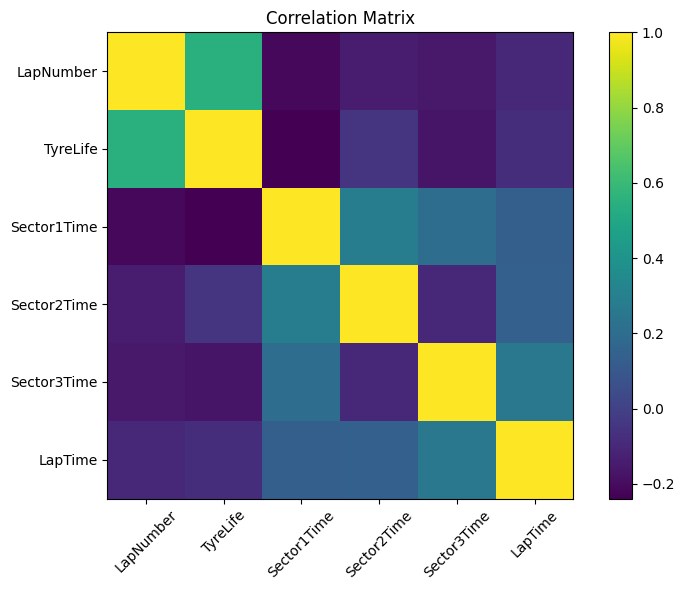

In [ ]:
# Data extraction and exploritatry data analysis

print("Driver Count:", f1["Driver"].nunique())
print("")
print("Total laps at each",f1["GrandPrix"].value_counts())
print("")
print("No. of laps with each Tyre",f1["Compound"].value_counts())
print("")
driver_average = (f1.groupby("Driver")["LapTime"].mean().sort_values())
print("Average lap time time by", driver_average)
print("")
driver_fastest = (f1.groupby("Driver")["LapTime"].min().sort_values())
print("Fastest lap time by",driver_fastest)
print("")
compound_average = (f1.groupby("Compound")["LapTime"].mean().sort_values())
print("Average lap time by",compound_average)
print("")
race_pace = f1[
    (f1["LapTime"] > 60) &
    (f1["LapTime"] < 110)
]
consistency = (
    race_pace.groupby("Driver")["LapTime"]
    .std()
    .sort_values()
)

print("Consistency (standard deviation of race pace in seconds)")
print(consistency)
print("")
correlation = f1[
    [
        "LapNumber",
        "TyreLife",
        "Sector1Time",
        "Sector2Time",
        "Sector3Time",
        "LapTime"
    ]
].corr()
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(correlation)
plt.xticks(range(len(correlation.columns)),
           correlation.columns,
           rotation=45)
plt.yticks(range(len(correlation.columns)),
           correlation.columns)
plt.colorbar()
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()




